In [1]:
import pandas as pd

df = pd.read_csv('healthcare_dataset.csv')

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [2]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Dataset Shape:
(55500, 15)

Column Names:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

Data Types:
Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

Missing Values:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0

In [3]:
# Make a copy of the original dataset
healthcare = df.copy()

# 1. Remove duplicate records
healthcare = healthcare.drop_duplicates()

# 2. Convert date columns to datetime
healthcare['Date of Admission'] = pd.to_datetime(
    healthcare['Date of Admission']
)

healthcare['Discharge Date'] = pd.to_datetime(
    healthcare['Discharge Date']
)

# 3. Calculate length of hospital stay
healthcare['Length of Stay'] = (
    healthcare['Discharge Date'] - healthcare['Date of Admission']
).dt.days

# 4. Create Year and Month columns
healthcare['Admission Year'] = healthcare['Date of Admission'].dt.year
healthcare['Admission Month'] = healthcare['Date of Admission'].dt.month
healthcare['Admission Month Name'] = healthcare['Date of Admission'].dt.month_name()

# 5. Create Year-Month column
healthcare['Year-Month'] = (
    healthcare['Date of Admission'].dt.to_period('M').astype(str)
)

# 6. Create Age Group
healthcare['Age Group'] = pd.cut(
    healthcare['Age'],
    bins=[0, 17, 30, 45, 60, 75, 120],
    labels=['0-17', '18-30', '31-45', '46-60', '61-75', '76+']
)

# Display cleaned dataset
healthcare.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,Admission Year,Admission Month,Admission Month Name,Year-Month,Age Group
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,...,Urgent,2024-02-02,Paracetamol,Normal,2,2024,1,January,2024-01,18-30
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,...,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,2019,8,August,2019-08,61-75
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,...,Emergency,2022-10-07,Aspirin,Normal,15,2022,9,September,2022-09,76+
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,...,Elective,2020-12-18,Ibuprofen,Abnormal,30,2020,11,November,2020-11,18-30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,...,Urgent,2022-10-09,Penicillin,Abnormal,20,2022,9,September,2022-09,31-45


In [4]:
print("Original Records:", len(df))
print("Records After Removing Duplicates:", len(healthcare))
print("Duplicates Removed:", df.duplicated().sum())

print("\nNew Columns:")
print(healthcare.columns.tolist())

print("\nLength of Stay Summary:")
print(healthcare['Length of Stay'].describe())

Original Records: 55500
Records After Removing Duplicates: 54966
Duplicates Removed: 534

New Columns:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'Length of Stay', 'Admission Year', 'Admission Month', 'Admission Month Name', 'Year-Month', 'Age Group']

Length of Stay Summary:
count    54966.000000
mean        15.499290
std          8.661471
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64


In [5]:
print("===== HEALTHCARE DATA ANALYSIS =====")

print("\nTotal Patient Records:", len(healthcare))

print(
    "Total Billing Amount:",
    round(healthcare['Billing Amount'].sum(), 2)
)

print(
    "Average Billing Amount:",
    round(healthcare['Billing Amount'].mean(), 2)
)

print(
    "Average Age:",
    round(healthcare['Age'].mean(), 2)
)

print(
    "Average Length of Stay:",
    round(healthcare['Length of Stay'].mean(), 2),
    "days"
)

print("\nMedical Condition:")
print(healthcare['Medical Condition'].value_counts())

print("\nAdmission Type:")
print(healthcare['Admission Type'].value_counts())

print("\nTest Results:")
print(healthcare['Test Results'].value_counts())

print("\nInsurance Provider:")
print(healthcare['Insurance Provider'].value_counts())

print("\nMedication:")
print(healthcare['Medication'].value_counts())

===== HEALTHCARE DATA ANALYSIS =====

Total Patient Records: 54966
Total Billing Amount: 1404068339.23
Average Billing Amount: 25544.31
Average Age: 51.54
Average Length of Stay: 15.5 days

Medical Condition:
Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

Admission Type:
Admission Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64

Test Results:
Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64

Insurance Provider:
Insurance Provider
Cigna               11139
Medicare            11039
UnitedHealthcare    11014
Blue Cross          10952
Aetna               10822
Name: count, dtype: int64

Medication:
Medication
Lipitor        11038
Ibuprofen      11023
Aspirin        10984
Paracetamol    10965
Penicillin     10956
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt

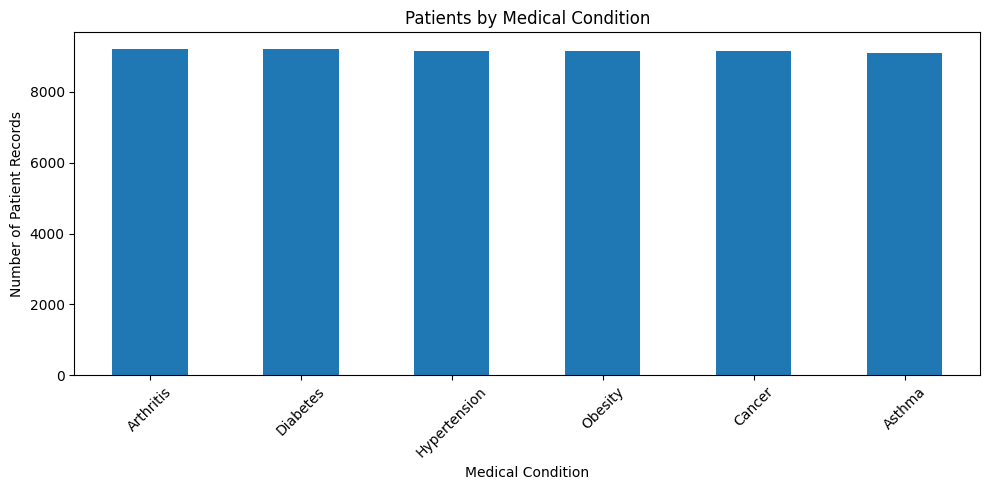

In [8]:
condition_counts = healthcare['Medical Condition'].value_counts()

plt.figure(figsize=(10, 5))
condition_counts.plot(kind='bar')

plt.title('Patients by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patient Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

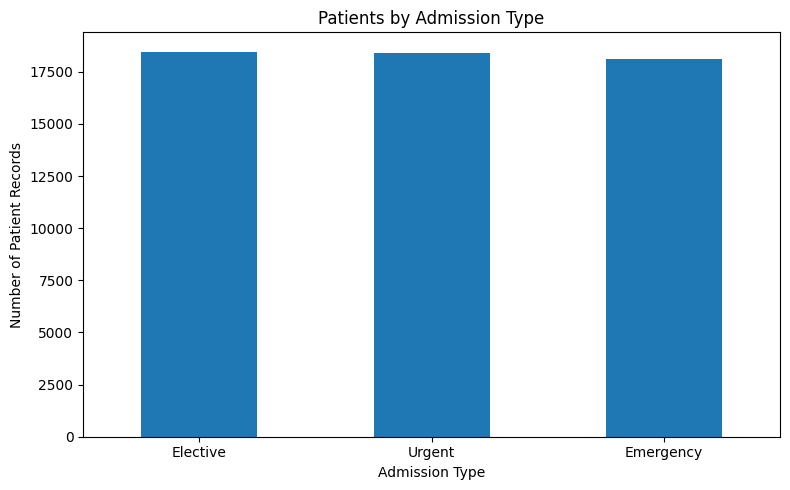

In [9]:
admission_counts = healthcare['Admission Type'].value_counts()

plt.figure(figsize=(8, 5))
admission_counts.plot(kind='bar')

plt.title('Patients by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Number of Patient Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

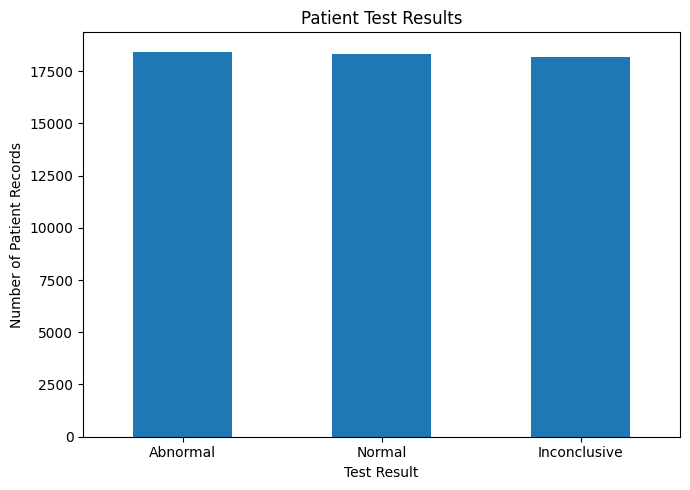

In [10]:
test_counts = healthcare['Test Results'].value_counts()

plt.figure(figsize=(7, 5))
test_counts.plot(kind='bar')

plt.title('Patient Test Results')
plt.xlabel('Test Result')
plt.ylabel('Number of Patient Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
billing_by_condition = healthcare.groupby(
    'Medical Condition'
)['Billing Amount'].mean().sort_values(ascending=False)

print("Average Billing Amount by Medical Condition:")
print(billing_by_condition.round(2))

Average Billing Amount by Medical Condition:
Medical Condition
Obesity         25804.36
Diabetes        25660.48
Asthma          25633.46
Arthritis       25511.78
Hypertension    25503.06
Cancer          25152.32
Name: Billing Amount, dtype: float64


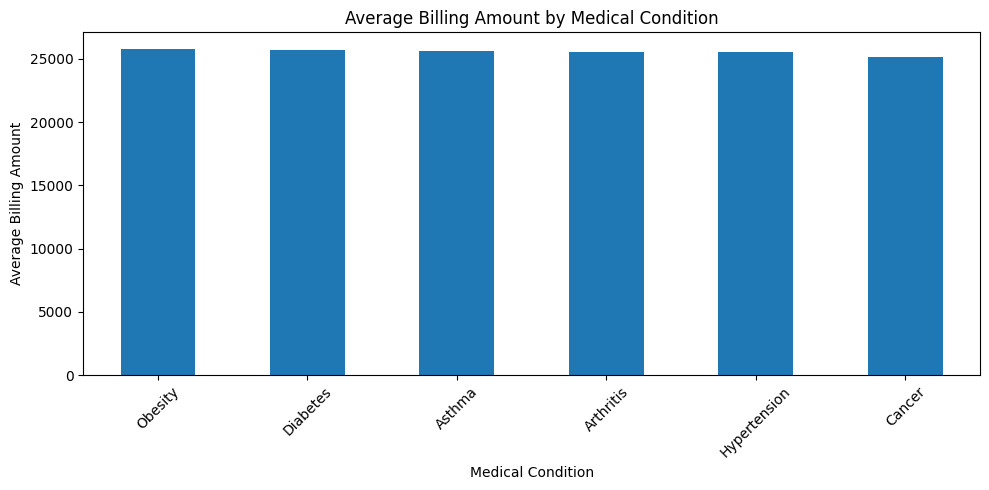

In [12]:
plt.figure(figsize=(10, 5))

billing_by_condition.plot(kind='bar')

plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
billing_by_insurance = healthcare.groupby(
    'Insurance Provider'
)['Billing Amount'].mean().sort_values(ascending=False)

print("Average Billing Amount by Insurance Provider:")
print(billing_by_insurance.round(2))

Average Billing Amount by Insurance Provider:
Insurance Provider
Medicare            25628.32
Blue Cross          25603.46
Aetna               25549.69
Cigna               25526.00
UnitedHealthcare    25414.51
Name: Billing Amount, dtype: float64


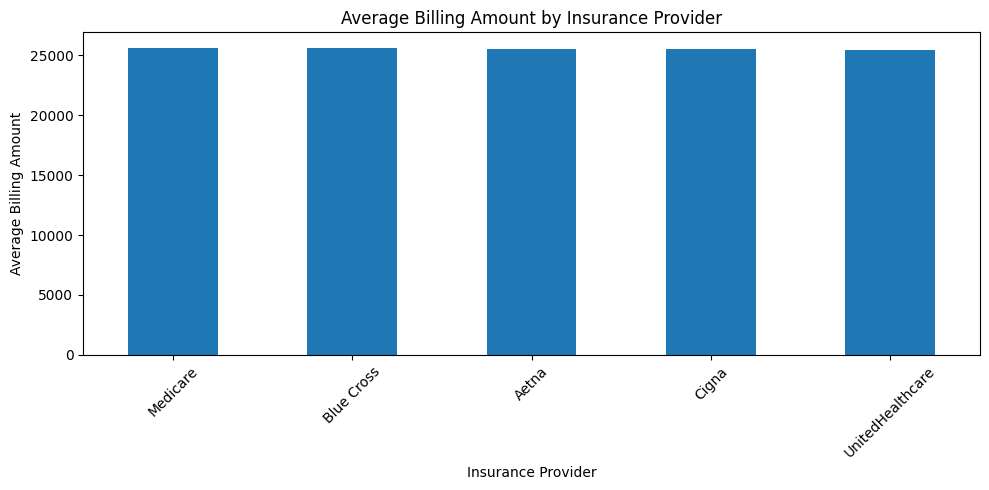

In [14]:
plt.figure(figsize=(10, 5))

billing_by_insurance.plot(kind='bar')

plt.title('Average Billing Amount by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

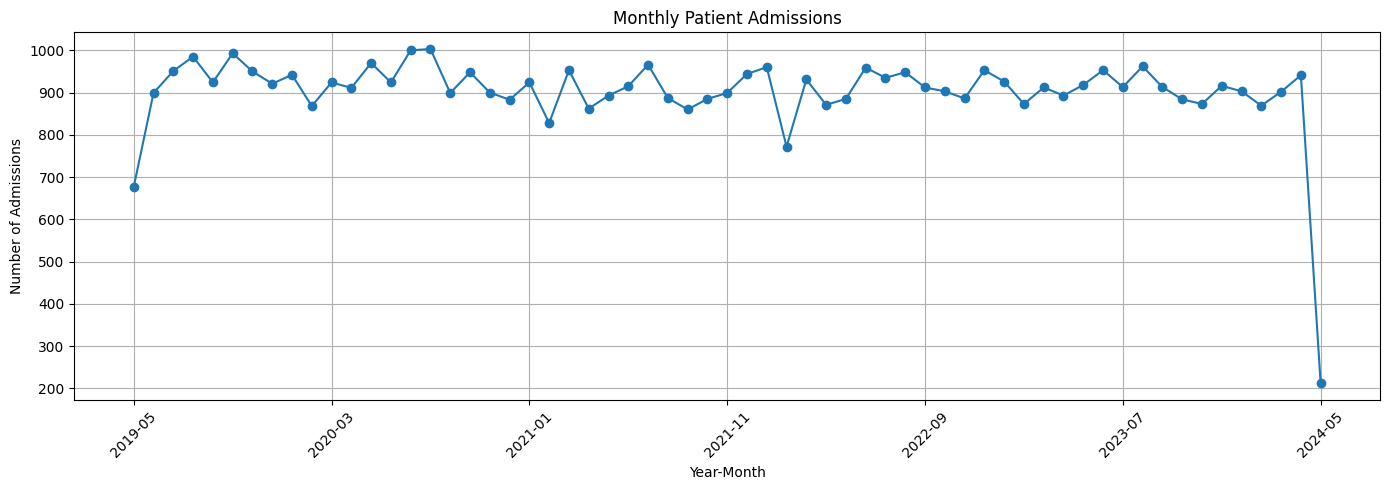

In [15]:
monthly_admissions = healthcare.groupby(
    'Year-Month'
).size()

plt.figure(figsize=(14, 5))
monthly_admissions.plot(kind='line', marker='o')

plt.title('Monthly Patient Admissions')
plt.xlabel('Year-Month')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

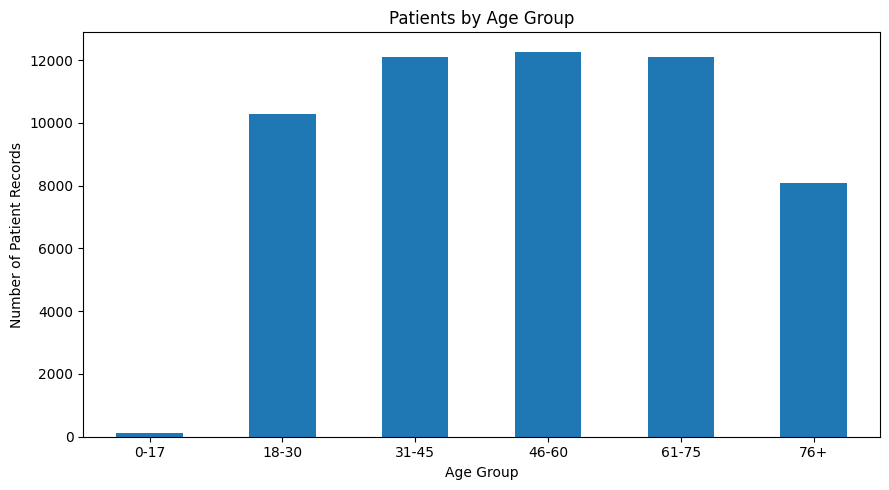

In [16]:
age_group_counts = healthcare['Age Group'].value_counts().sort_index()

plt.figure(figsize=(9, 5))
age_group_counts.plot(kind='bar')

plt.title('Patients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patient Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

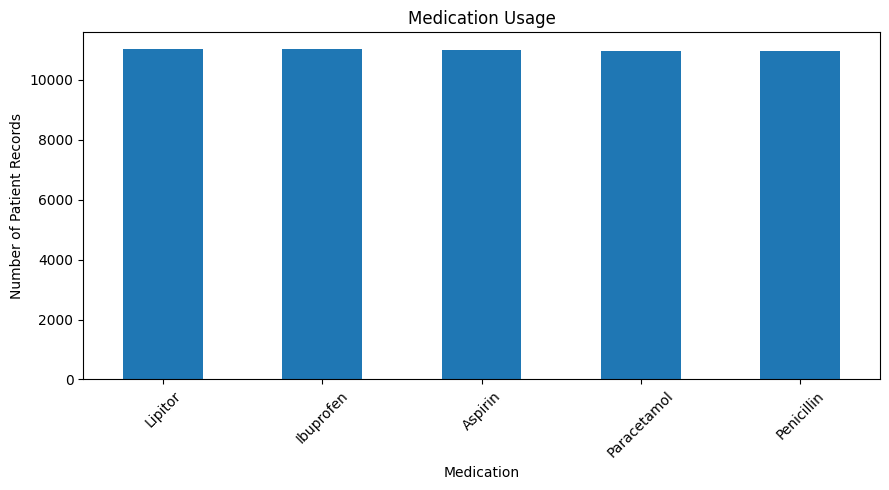

In [17]:
medication_counts = healthcare['Medication'].value_counts()

plt.figure(figsize=(9, 5))
medication_counts.plot(kind='bar')

plt.title('Medication Usage')
plt.xlabel('Medication')
plt.ylabel('Number of Patient Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
print("===== FINAL HEALTHCARE SUMMARY =====")

print("Total Records:", len(healthcare))
print("Total Billing Amount:", round(healthcare['Billing Amount'].sum(), 2))
print("Average Billing Amount:", round(healthcare['Billing Amount'].mean(), 2))
print("Average Age:", round(healthcare['Age'].mean(), 2))
print("Average Length of Stay:", round(healthcare['Length of Stay'].mean(), 2), "days")

print("\nMost Common Medical Condition:")
print(healthcare['Medical Condition'].value_counts().idxmax())

print("\nMost Common Admission Type:")
print(healthcare['Admission Type'].value_counts().idxmax())

print("\nMost Common Medication:")
print(healthcare['Medication'].value_counts().idxmax())

print("\nTest Results:")
print(healthcare['Test Results'].value_counts())

===== FINAL HEALTHCARE SUMMARY =====
Total Records: 54966
Total Billing Amount: 1404068339.23
Average Billing Amount: 25544.31
Average Age: 51.54
Average Length of Stay: 15.5 days

Most Common Medical Condition:
Arthritis

Most Common Admission Type:
Elective

Most Common Medication:
Lipitor

Test Results:
Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64
